Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Data Preprocessing

Training image preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


Validation image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


To avoid overshooting loss function
1. Choose small learning rate here default rate is 0.001 but we will take 0.0001
2. There may be a chance of underfitting so we will increase the number of neurons
3. Add more convulational layer to extract more feature from image

Building Model

In [4]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [5]:
model = Sequential()

In [6]:
##Building Convulational Layer

In [7]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [8]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [9]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(tf.keras.layers.Dropout(0.25))#to avoid overfitting

In [13]:
# flatenning operation
model.add(Flatten())

In [14]:
model.add(Dense(units=1500,activation='relu'))

In [15]:
model.add(tf.keras.layers.Dropout(0.4))#to avoid overfitting

In [16]:
#output layer
model.add(Dense(units=38,activation='softmax'))

Compiling Model

In [17]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001) ,loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

Model Training

In [20]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


2197/2197 [==============================] - 1663s 757ms/step - loss: 0.1794 - accuracy: 0.9417 - val_loss: 0.1628 - val_accuracy: 0.9488
Epoch 2/10
2197/2197 [==============================] - 1632s 743ms/step - loss: 0.1329 - accuracy: 0.9563 - val_loss: 0.1968 - val_accuracy: 0.9388
Epoch 3/10
2197/2197 [==============================] - 1660s 756ms/step - loss: 0.1053 - accuracy: 0.9655 - val_loss: 0.1268 - val_accuracy: 0.9601
Epoch 4/10
2197/2197 [==============================] - 1628s 741ms/step - loss: 0.0868 - accuracy: 0.9721 - val_loss: 0.1376 - val_accuracy: 0.9596
Epoch 5/10
2197/2197 [==============================] - 1644s 748ms/step - loss: 0.0702 - accuracy: 0.9771 - val_loss: 0.1435 - val_accuracy: 0.9586
Epoch 6/10
2197/2197 [==============================] - 1641s 747ms/step - loss: 0.0671 - accuracy: 0.9788 - val_loss: 0.1143 - val_accuracy: 0.9653
Epoch 7/10
2197/2197 [==============================] - 1646s 749ms/step - loss: 0.0541 - accuracy: 0.9831 - val_loss

Model Evaluation

In [21]:
#Model evaluation on training set
train_loss, train_acc=model.evaluate(training_set)


2197/2197 [==============================] - 434s 198ms/step - loss: 0.0204 - accuracy: 0.9935


In [23]:
print(train_loss,train_acc)

0.02035532519221306 0.9935130476951599


In [24]:
val_loss,val_acc=model.evaluate(validation_set)

550/550 [==============================] - 109s 198ms/step - loss: 0.1007 - accuracy: 0.9723


In [25]:
print(val_loss,val_acc)

0.10074951499700546 0.9723423719406128


Saving Model

In [27]:
model.save("trained_model.keras")

In [28]:
training_history.history #return dictionary of history

{'loss': [0.1793786734342575,
  0.13292238116264343,
  0.10534466058015823,
  0.08684523403644562,
  0.07022399455308914,
  0.06711329519748688,
  0.054131973534822464,
  0.05315066874027252,
  0.0430716797709465,
  0.03977568447589874],
 'accuracy': [0.9417028427124023,
  0.9562557935714722,
  0.9654740691184998,
  0.9720606207847595,
  0.9770538210868835,
  0.9788463115692139,
  0.9831424951553345,
  0.9831282496452332,
  0.9865566492080688,
  0.9869407415390015],
 'val_loss': [0.16275548934936523,
  0.1967972218990326,
  0.126785546541214,
  0.1376199722290039,
  0.14353317022323608,
  0.1142997071146965,
  0.1509442925453186,
  0.1462356299161911,
  0.0971546620130539,
  0.10074952989816666],
 'val_accuracy': [0.9488390684127808,
  0.9388231039047241,
  0.9601069688796997,
  0.9595947861671448,
  0.9585704803466797,
  0.9652856588363647,
  0.9587411880493164,
  0.9573753476142883,
  0.9721716642379761,
  0.9723423719406128]}

In [29]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

Accuracy Visualization

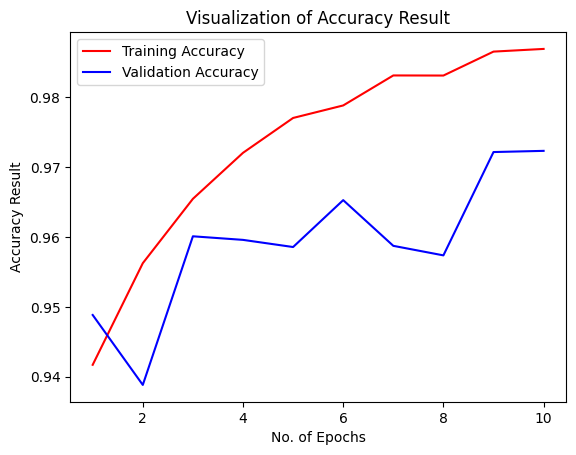

In [33]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy Result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

Some other metrices for model evaluation

In [35]:
# class_name = validation_set.class_names
# class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [36]:
# test_set = tf.keras.utils.image_dataset_from_directory(
#     'valid',
#     labels="inferred",
#     label_mode="categorical",
#     class_names=None,
#     color_mode="rgb",
#     batch_size=1,
#     image_size=(128, 128),
#     shuffle=False,
#     seed=None,
#     validation_split=None,
#     subset=None,
#     interpolation="bilinear",
#     follow_links=False,
#     crop_to_aspect_ratio=False
# )

Found 17572 files belonging to 38 classes.


In [37]:
# y_pred = model.predict(test_set)
# predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 [==============================] - 304s 17ms/step


In [38]:
# true_categories = tf.concat([y for x, y in test_set], axis=0)
# Y_true = tf.argmax(true_categories, axis=1)

In [39]:
# Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [40]:
# predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [41]:
# from sklearn.metrics import confusion_matrix,classification_report
# cm = confusion_matrix(Y_true,predicted_categories)

In [42]:
# # Precision Recall Fscore
# print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.98      0.97       504
                                 Apple___Black_rot       0.99      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.99      0.99       440
                                   Apple___healthy       0.99      0.96      0.97       502
                               Blueberry___healthy       0.98      0.98      0.98       454
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.85      0.91       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.99      0.

In [44]:
# cn=confusion_matrix(Y_true,predicted_categories)
# cn

array([[492,   1,   0, ...,   0,   0,   0],
       [  0, 496,   0, ...,   0,   0,   0],
       [  0,   0, 436, ...,   0,   0,   0],
       ...,
       [  0,   0,   1, ..., 481,   0,   0],
       [  0,   0,   0, ...,   0, 434,   0],
       [  0,   0,   1, ...,   0,   0, 461]], dtype=int64)

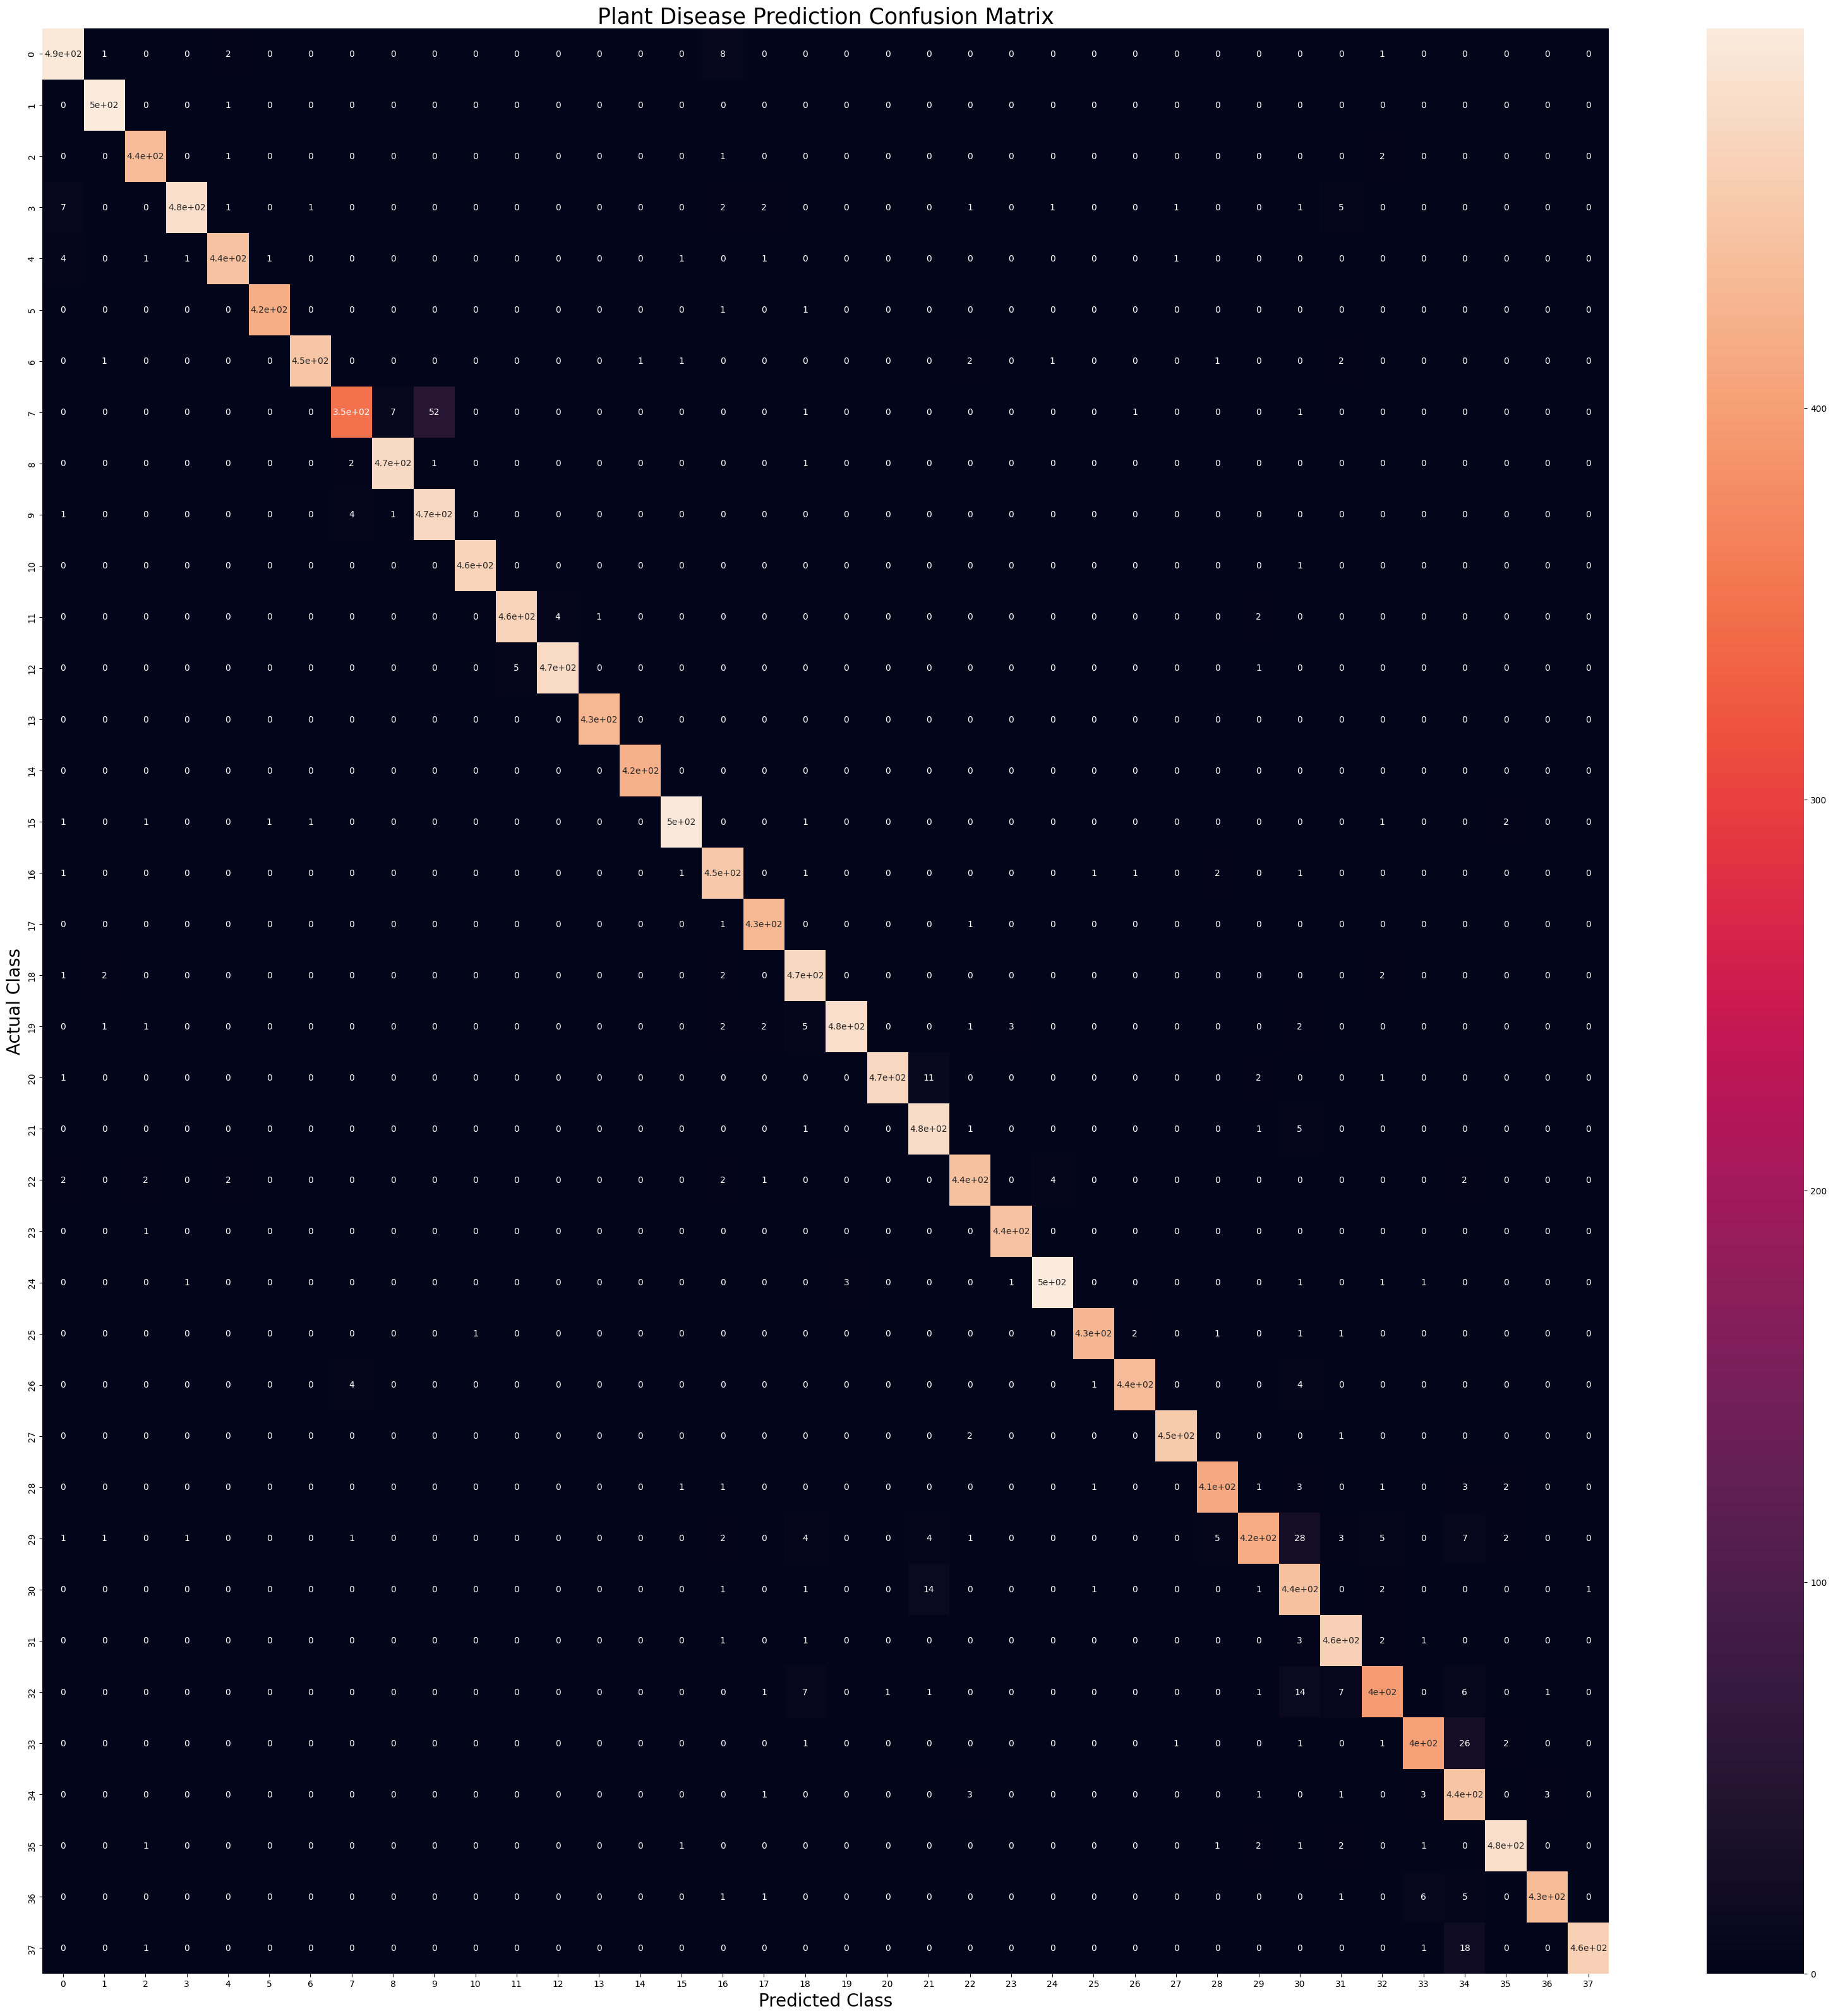

In [45]:
# plt.figure(figsize=(40, 40))
# sns.heatmap(cm,annot=True,annot_kws={"size": 10})

# plt.xlabel('Predicted Class',fontsize = 20)
# plt.ylabel('Actual Class',fontsize = 20)
# plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
# plt.show()